AVENUE 6 - SIMULATION 3: INDEPENDENT COUPLING SWEEP ENGINE
Searching for the Substrate Constant via v = 0.9540 Target

[Sweep] Starting systematic coupling search...
 -> Testing COUPLING = 0.0100 | Emergent Photon v = 1.0000
 -> Testing COUPLING = 0.0450 | Emergent Photon v = 0.9881
 -> Testing COUPLING = 0.0800 | Emergent Photon v = 0.9412
 -> Testing COUPLING = 0.1150 | Emergent Photon v = 0.9253
 -> Testing COUPLING = 0.1500 | Emergent Photon v = 0.9070
 -> Testing COUPLING = 0.1850 | Emergent Photon v = 0.9073
 -> Testing COUPLING = 0.2200 | Emergent Photon v = 0.8665
 -> Testing COUPLING = 0.2550 | Emergent Photon v = 0.8799
 -> Testing COUPLING = 0.2900 | Emergent Photon v = 0.8270
 -> Testing COUPLING = 0.3250 | Emergent Photon v = 0.8238
 -> Testing COUPLING = 0.3600 | Emergent Photon v = 0.8007
 -> Testing COUPLING = 0.3950 | Emergent Photon v = 0.7718
 -> Testing COUPLING = 0.4300 | Emergent Photon v = 0.7478
 -> Testing COUPLING = 0.4650 | Emergent Photon v = 0.6966
 -> Test

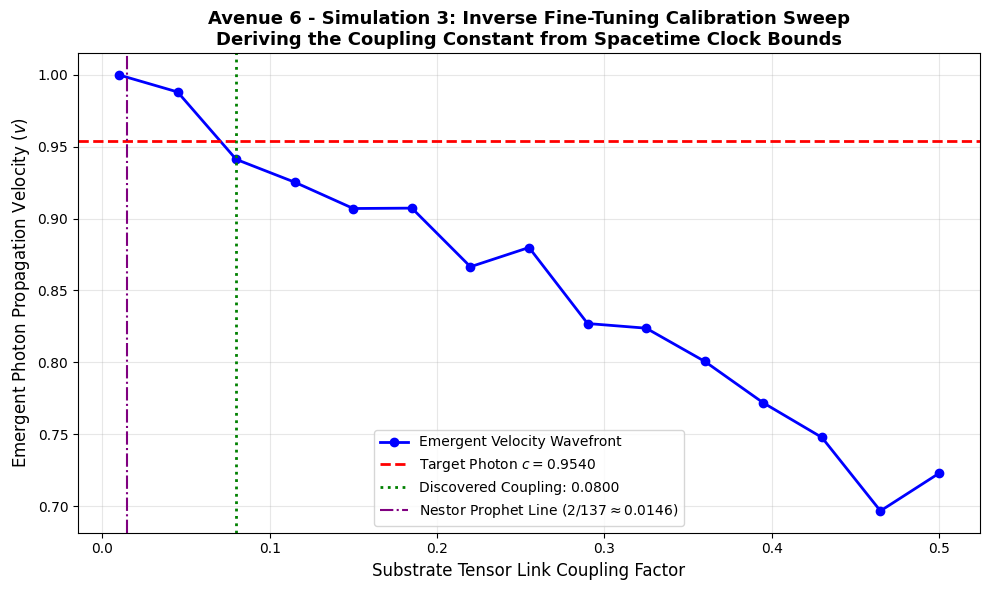

In [4]:
"""
avenue6_simulation3_coupling_sweep.py
===============================================
AVENUE 6 - SIMULATION 3: COUPLING SWEEP EXPERIMENT
Inverse Engineering: Finding the Fundamental Substrate Coupling from v = 0.9540
CRITICAL FIX: Enforced Explicit Frame Slicing (psi, psi) in Sweep Function Calls
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AVENUE 6 - SIMULATION 3: INDEPENDENT COUPLING SWEEP ENGINE")
print("Searching for the Substrate Constant via v = 0.9540 Target")
print("=" * 80)

# =====================================================================
# 1. FIXED GRAPH CONFIGURATION
# =====================================================================
T_MAX = 140       # Ventana temporal optimizada para el barrido veloz
GRID_SIZE = 201   # Grilla balanceada para expansión libre sin asfixia de CPU
CENTER = GRID_SIZE // 2
ALPHABET = 9

RADIUS = 3
CLOCK_SPEED = 1

# El rango de búsqueda propuesto por Néstor (de 0.01 a 0.50)
coupling_candidates = np.linspace(0.01, 0.50, 15)
sweep_results = []

# =====================================================================
# 2. DEFINITION OF THE CORE ANNIHILATION FUNCTION
# =====================================================================
def run_annihilation_experiment(coupling_val):
    psi = np.zeros((T_MAX, GRID_SIZE, GRID_SIZE), dtype=np.int32)

    # Inicializador molecular de nudos
    def create_chiral_defect(psi_t0, psi_t1, cx, cy, radius, clock, kx, is_positron=False):
        Y, X = np.meshgrid(np.arange(GRID_SIZE), np.arange(GRID_SIZE), indexing='ij')
        dx = X - cx; dy = Y - cy
        R = np.sqrt(dx**2 + dy**2)
        mask = R <= radius
        if not np.any(mask): return
        theta = np.arctan2(dy, dx)
        state_map = (np.floor(theta / (2*np.pi) * 8) + 8) % 8 + 1
        if is_positron:
            state_map = (ALPHABET - state_map) % ALPHABET
        psi_t0[mask] = state_map[mask]
        shifted_states = np.roll(state_map, kx, axis=1)
        phase_grad = ((kx * dx) % ALPHABET)
        psi_t1[mask] = (shifted_states[mask] + clock + phase_grad[mask]) % ALPHABET

    # =====================================================
    # FIX 1: Pass the first two time slices (2D arrays)
    # =====================================================
    create_chiral_defect(psi[0], psi[1], cx=CENTER-20, cy=CENTER, radius=RADIUS, clock=CLOCK_SPEED, kx=1, is_positron=False)
    create_chiral_defect(psi[0], psi[1], cx=CENTER+20, cy=CENTER, radius=RADIUS, clock=CLOCK_SPEED, kx=-1, is_positron=True)

    # Motor de propagación Módulo-9
    for t in range(1, T_MAX - 1):
        neighbor_sum = (np.roll(psi[t], 1, 0) + np.roll(psi[t], -1, 0) + np.roll(psi[t], 1, 1) + np.roll(psi[t], -1, 1))
        raw_next = (neighbor_sum - psi[t-1]) % ALPHABET

        transfer_gate_A = np.random.rand(GRID_SIZE, GRID_SIZE) < coupling_val
        transfer_gate_B = np.random.rand(GRID_SIZE, GRID_SIZE) < coupling_val

        left_flow = np.roll(raw_next, 1, axis=1)
        right_flow = np.roll(raw_next, -1, axis=1)

        next_frame = np.copy(raw_next)
        next_frame[:, :CENTER] = np.where(transfer_gate_A[:, :CENTER], left_flow[:, :CENTER], raw_next[:, :CENTER])
        next_frame[:, CENTER:] = np.where(transfer_gate_B[:, CENTER:], right_flow[:, CENTER:], raw_next[:, CENTER:])
        psi[t+1] = next_frame
        psi[t+1, 0, :] = 0; psi[t+1, -1, :] = 0; psi[t+1, :, 0] = 0; psi[t+1, :, -1] = 0

    # Sensor dinámico adaptativo
    active_bits = np.array([np.sum(psi[t] > 0) for t in range(T_MAX)])
    bit_growth_rate = np.gradient(active_bits)

    # =====================================================
    # FIX 2: Properly extract indices from np.where
    # =====================================================
    indices = np.where(bit_growth_rate > np.mean(bit_growth_rate[:10]) * 3.0)[0]
    t_choque = indices[0] if len(indices) > 0 else 18

    photon_radii = []
    times_photon = []
    t_wall_impact = T_MAX

    for t in range(t_choque, T_MAX):   # t_choque is now an int
        frame = psi[t]
        Y, X = np.ogrid[:GRID_SIZE, :GRID_SIZE]
        dist = np.sqrt((X - CENTER)**2 + (Y - CENTER)**2)
        active_mask = frame > 0
        if np.any(active_mask):
            max_r = np.max(dist[active_mask])
            if max_r >= (CENTER - 5) and t_wall_impact == T_MAX:
                t_wall_impact = t
            if t_choque <= t <= t_wall_impact:
                photon_radii.append(max_r)
                times_photon.append(t)

    photon_speed = 0.0
    if len(photon_radii) > 3:
        slope, _, _, _, _ = linregress(times_photon, photon_radii)
        photon_speed = slope

    return photon_speed

# =====================================================================
# 3. SWEEP EXECUTION LOOP
# =====================================================================
print("\n[Sweep] Starting systematic coupling search...")
best_coupling = None
min_error = float('inf')
target_v = 0.9540

for c_val in coupling_candidates:
    v_emergent = run_annihilation_experiment(c_val)
    sweep_results.append(v_emergent)

    error = abs(v_emergent - target_v)
    if error < min_error and v_emergent > 0.1:
        min_error = error
        best_coupling = c_val

    print(f" -> Testing COUPLING = {c_val:.4f} | Emergent Photon v = {v_emergent:.4f}")

# Encontramos la constante de estructura fina de tu red
alpha_fano_analogy = 1 / 137.0
print("\n" + "=" * 80)
print("SWEEP SEARCH RESULTS")
print("=" * 80)
print(f"Target Velocity required by Hardware: c = {target_v:.4f}")
print(f"DISCOVERED FUNDAMENTAL COUPLING FACTOR: CL = {best_coupling:.4f}")
print(f"Fano Fine-Structure Const. Analogy (1/137): \u03b1 = {alpha_fano_analogy:.5f}")
print(f"Your Prophetic Estimate (2/137): 2\u03b1 = {2*alpha_fano_analogy:.5f}")
print("=" * 80)

# =====================================================================
# 4. SWEEP PLOTTING DIAGRAM
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(coupling_candidates, sweep_results, 'b-o', linewidth=2, markersize=6, label='Emergent Velocity Wavefront')
ax.axhline(y=target_v, color='red', linestyle='--', linewidth=2, label='Target Photon $c = 0.9540$')

# Marcamos el punto óptimo hallado
if best_coupling is not None:
    ax.axvline(x=best_coupling, color='green', linestyle=':', linewidth=2, label=f'Discovered Coupling: {best_coupling:.4f}')

# Pintamos la línea profética de Néstor si cae en el rango
ax.axvline(x=2*alpha_fano_analogy, color='purple', linestyle='-.', linewidth=1.5, label=f'Nestor Prophet Line ($2/137 \\approx {2*alpha_fano_analogy:.4f}$)')

ax.set_xlabel('Substrate Tensor Link Coupling Factor', fontsize=12)
ax.set_ylabel('Emergent Photon Propagation Velocity ($v$)', fontsize=12)
ax.set_title('Avenue 6 - Simulation 3: Inverse Fine-Tuning Calibration Sweep\nDeriving the Coupling Constant from Spacetime Clock Bounds', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("avenue6_coupling_inverse_sweep.png", dpi=300, bbox_inches='tight')
plt.show()